## This repository contains an exploratory data analysis (EDA) of the bank's customers based on the **BankChurners** dataset.

### Libraries used: Pandas, Matplotlib, Plotly.
#### Author: Sergey Babayan

### The main goal is to understand what factors influence **customer churn** and to identify key patterns in customer demographics, financial behavior, and activity.

In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

### This block reads, processes, and displays the first 5 lines of each variable. 

In [6]:
mainData = pd.read_csv('datasets/BankChurners.csv')

print(mainData.head())

   CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Credit_Limit  Total_Revolving_Bal  Avg_Open_To_Buy  \
0              39  ...       12691.0                  777          11914.0   
1       

## Description of the dataset

### **10 127 lines**, **23 columns**, **No missed beats**.

Key numerical indicators:

| Feature | Average | Min | Max |
|---|---|---|---|
| Customer_Age | 46.3 | 26 | 73 |
| Months_on_book | 35.9 | 13 | 56 |
| Credit_Limit | 8 631 | 1 438 | 34 516 |
| Total_Trans_Amt | 4 404 | 510 | 18 484 |
| Total_Trans_Ct | 64.9 | 10 | 139 |
| Avg_Utilization_Ratio | 0.27 | 0 | 1 |

In [23]:
print(mainData.describe())

print('-' * 50)

print(mainData.isnull().sum())

          CLIENTNUM  Customer_Age  Dependent_count  Months_on_book  \
count  1.012700e+04  10127.000000     10127.000000    10127.000000   
mean   7.391776e+08     46.325960         2.346203       35.928409   
std    3.690378e+07      8.016814         1.298908        7.986416   
min    7.080821e+08     26.000000         0.000000       13.000000   
25%    7.130368e+08     41.000000         1.000000       31.000000   
50%    7.179264e+08     46.000000         2.000000       36.000000   
75%    7.731435e+08     52.000000         3.000000       40.000000   
max    8.283431e+08     73.000000         5.000000       56.000000   

       Total_Relationship_Count  Months_Inactive_12_mon  \
count              10127.000000            10127.000000   
mean                   3.812580                2.341167   
std                    1.554408                1.010622   
min                    1.000000                0.000000   
25%                    3.000000                2.000000   
50%            

## Customer distribution by age

The distribution is close to **normal**, with the peak occurring between **44 and 50 years of age**.

- Most customers are middle-aged
- There are very few customers under 30 or over 65
- Average age: **46.3 years**, range: 26–73

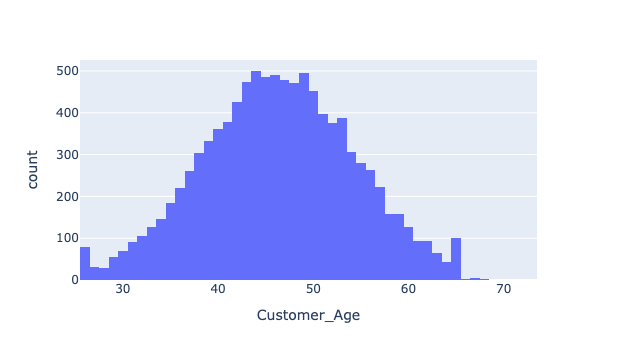

In [9]:
px.histogram(mainData, x="Customer_Age")

## Customer churn by income level

The `Unknown` category has been excluded from the analysis as it is not informative.

- The largest number of customers falls into the **Less than $40K** income bracket—and the absolute number of churned customers is also higher in this group
- However, the **churn rate is roughly the same** across all income categories
- Income level **is not a key factor** in churn

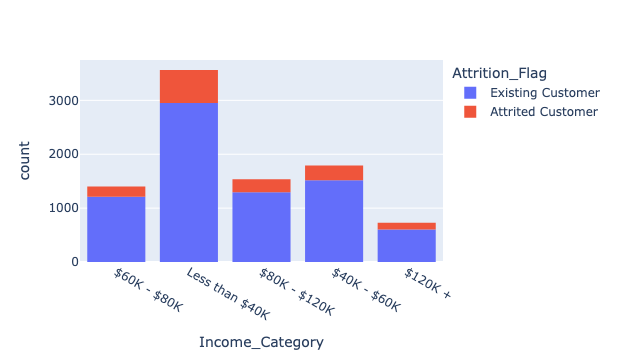

In [18]:
px.histogram(
    mainData[mainData["Income_Category"] != "Unknown"],
    x="Income_Category",
    color="Attrition_Flag"
)

## Customer Churn by Gender

### “F” and “M” in the graph stand for female and male, accordingly.
- There are slightly **more** women than men in the dataset
- The proportion of churned customers is **roughly the same** for both genders
- Gender **is not a significant predictor** of churn

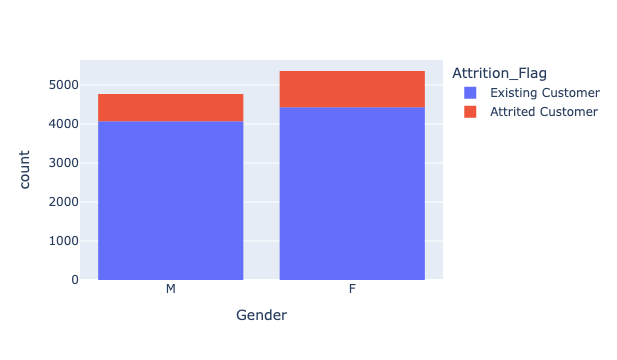

In [20]:
px.histogram(mainData, x="Gender", color="Attrition_Flag")

## Churn by Months of Inactivity

The chart shows the percentage of customers who have left versus those who have remained, based on
how many months over the past year they have not performed any transactions.

**What the graph shows:**

- **0 months of inactivity** - churn rate of about 50%. This appears to be an anomaly:
  these are likely customers who closed their accounts immediately after opening them,
  before having a chance to become active
- **1 month** — minimal churn (~5%). The customer has recently interacted with the bank
  and remains loyal
- **2 months** — moderate churn (~15%); most customers still remain
- **3–4 months** — a noticeable jump to **~30–35%**. This is where the
  critical threshold lies: the customer begins to “leave”
- **5–6 months** — churn decreases slightly again, but this may be due
  to the small number of observations in these groups

**Conclusion:** `Months_Inactive_12_mon` is one of the **strongest predictors** of churn.
Customers who have been inactive for 3 months or more require special attention
and targeted retention campaigns.

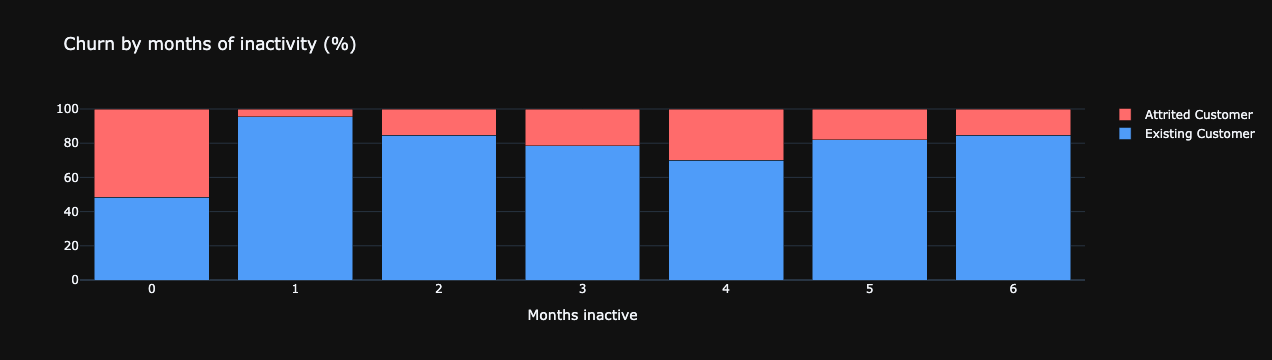

In [39]:
inact = mainData.groupby(["Months_Inactive_12_mon", "Attrition_Flag"]).size().unstack(fill_value=0)
inact_pct = inact.div(inact.sum(axis=1), axis=0) * 100

fig = go.Figure()
for col, color in [("Existing Customer", "#4F9CF9"), ("Attrited Customer", "#FF6B6B")]:
    if col in inact_pct.columns:
        fig.add_trace(go.Bar(x=inact_pct.index, y=inact_pct[col], name=col, marker_color=color))
fig.update_layout(barmode="stack", title="Churn by months of inactivity (%)",
                   xaxis_title="Months inactive", template="plotly_dark")
fig.show()

## Transaction Activity: Volume vs. Value

The scatter plot shows 3,000 random customers. The axes represent the number of transactions
per year (`Total_Trans_Ct`) and their total value (`Total_Trans_Amt`).

**What the graph shows:**

- **Red dots (churned customers)** are concentrated in the lower left quadrant—
  few transactions and small amounts. Most fall within the range
  of 10–60 transactions and up to $5k–$10k per year
- **Blue dots (remaining)** occupy the entire graph, but are particularly
  dense on the right side—80 transactions and above
- With **100+ transactions**, there are practically no churned customers—this is the zone
  of highly loyal customers
- Interestingly, at the average number of transactions (40–70), the clusters of red and blue
  dots **overlap significantly** — transaction activity alone is not enough
  to predict churn with certainty

**Conclusion:** `Total_Trans_Ct` and `Total_Trans_Amt` are the **strongest predictors** of churn.
Customers with fewer than 40–50 transactions per year are at risk.

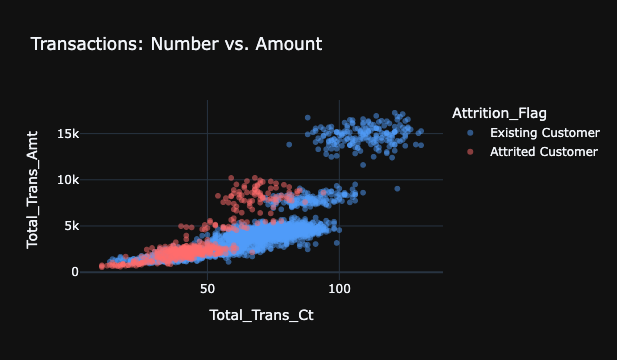

In [30]:
sample = mainData.sample(min(3000, len(mainData)), random_state=42)
fig2 = px.scatter(
    sample, x="Total_Trans_Ct", y="Total_Trans_Amt", color="Attrition_Flag",
    color_discrete_map={"Existing Customer": "#4F9CF9", "Attrited Customer": "#FF6B6B"},
    opacity=0.5, title="Transactions: Number vs. Amount", template="plotly_dark"
)
fig2.show()

## Churn by Number of Bank Contacts

The graph shows the percentage of customers who have left versus those who have remained, based on
how many times they contacted the bank over the past year.

**What the graph shows:**

- **0–1 contacts** — churn is minimal (~5–10%). The customer is satisfied and does not need
  support
- **2–3 contacts** — churn increases moderately to ~20–25%. The customer begins
  to experience difficulties or doubts
- **4–5 contacts** — churn rises sharply to **~35–40%**. Frequent contact
  signals dissatisfaction with the product or service
- **6 inquiries** — critical zone: churn reaches nearly **100%**.
  A customer who has contacted the bank 6 times in a year has, with high probability, already decided to leave

**Conclusion:** Paradoxically, **more contacts with the bank = higher churn risk**.
This does not mean that contacts cause churn—rather, frequent inquiries
are a symptom of problems the bank has been unable to resolve.
`Contacts_Count_12_mon` — **one of the key warning signs** for the retention team.

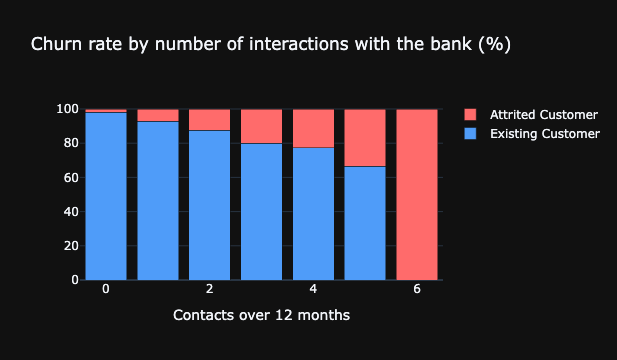

In [34]:
contacts = mainData.groupby(["Contacts_Count_12_mon", "Attrition_Flag"]).size().unstack(fill_value=0)
contacts_pct = contacts.div(contacts.sum(axis=1), axis=0) * 100

fig6 = go.Figure()
for col, color in [("Existing Customer", "#4F9CF9"), ("Attrited Customer", "#FF6B6B")]:
    if col in contacts_pct.columns:
        fig6.add_trace(go.Bar(x=contacts_pct.index, y=contacts_pct[col], name=col, marker_color=color))
fig6.update_layout(barmode="stack", title="Churn rate by number of interactions with the bank (%)",
                   xaxis_title="Contacts over 12 months", template="plotly_dark")
fig6.show()

## Clusterization 
### If the clusters are clearly separated by churn, it means that behavioral patterns actually exist and are not random.

### We can test the hypothesis: **customers prone to churn form a distinct behavioral segment**, distinguishable from loyal customers by transaction activity, credit behavior, and engagement.


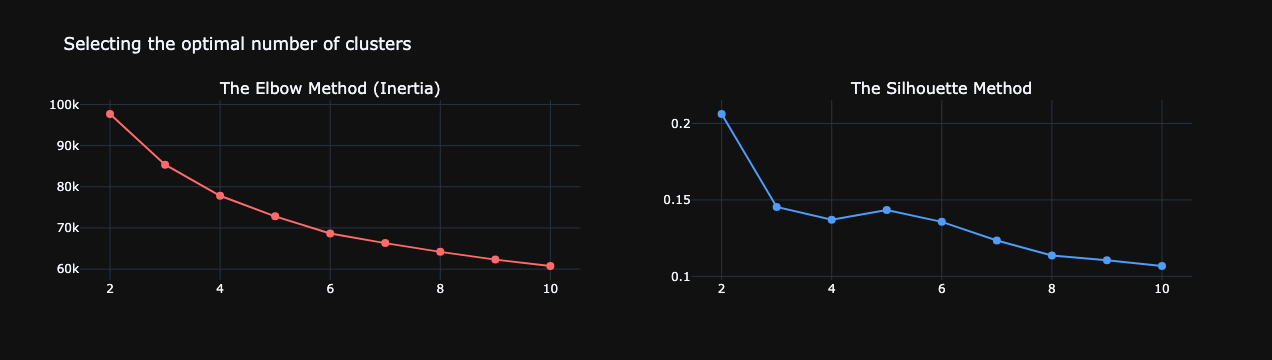

In [61]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots

num_cols = [
    "Customer_Age", "Dependent_count", "Months_on_book",
    "Total_Relationship_Count", "Months_Inactive_12_mon",
    "Contacts_Count_12_mon", "Credit_Limit", "Total_Revolving_Bal",
    "Total_Trans_Amt", "Total_Trans_Ct", "Avg_Utilization_Ratio"
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[num_cols])

inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig = make_subplots(rows=1, cols=2,
                    subplot_titles=["The Elbow Method (Inertia)", "The Silhouette Method"])

fig.add_trace(go.Scatter(
    x=list(K_range), y=inertias,
    mode="lines+markers",
    marker=dict(color="#FF6B6B", size=8),
    line=dict(color="#FF6B6B", width=2),
    name="Inertia"
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=list(K_range), y=silhouettes,
    mode="lines+markers",
    marker=dict(color="#4F9CF9", size=8),
    line=dict(color="#4F9CF9", width=2),
    name="Silhouette"
), row=1, col=2)

fig.update_layout(
    title="Selecting the optimal number of clusters",
    template="plotly_dark",
    showlegend=False
)
fig.show()

## Based on the elbow method and the silhouette method, the number of clusters was set to 3

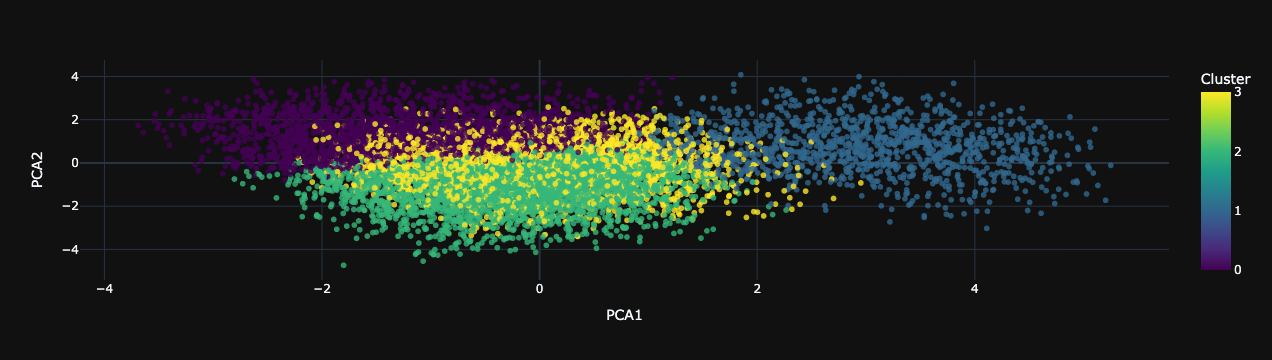

In [70]:
from sklearn.decomposition import PCA

K = 4

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X_scaled)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df["PCA1"] = coords[:, 0]
df["PCA2"] = coords[:, 1]

fig_clusters = px.scatter(
    df, x="PCA1", y="PCA2", color="Cluster",
    color_continuous_scale="Viridis",
    template="plotly_dark", opacity=0.8
)

fig_clusters.show()

In [ ]:
profile = df.groupby("Cluster")[num_cols + ["Attrition"]].mean().round(2)
print(profile)

### Results

| Cluster | Profile | Attrition |
|---|---|---|
| 0 | Average activity, low utilization, card rarely used | **26%** |
| 1 | High activity, many transactions, high limit | **6%** |
| 2 | Average activity, high utilization, low limit | **9%** |

### Conclusion

The hypothesis has been confirmed. Cluster 0 is a clear **risk group**: customers
hold the card but hardly ever use it. Low utilization with a
relatively high limit suggests that the product does not meet
their needs. These customers churn 4 times more often than
active users from Cluster 1.

---
### What We Learned from the Charts

**Demographics do not predict churn.**
The age distribution of customers follows a normal curve, peaking at 44–50 years old.
However, neither age, gender, nor income level showed
a significant correlation with churn—the percentage of customers who left is roughly
the same across all demographic groups. This is an important finding:
the bank should not target retention campaigns based on demographics.

**Behavior is the key indicator.**
Two charts provided the strongest insights:

- Customers with fewer than 40–50 transactions per year and a total
  balance of up to $3–5k are clearly at risk. Highly active customers
  (100+ transactions) rarely churn
- The longer a customer is inactive, the higher the likelihood of churn.
  The critical threshold is **3 months without activity**

**Frequent contact with the bank is a red flag.**
Paradoxically, customers who contact the bank 5–6 times a year are
almost guaranteed to leave. This means the bank is not resolving
customers’ issues when they reach out, which is what drives them away.

Factors that **do not influence** churn: age, gender, income level,
marital status—stereotypical assumptions about the profile
of an "unreliable customer" have not been confirmed.

**Key recommendation:** An early churn warning system
should rely on real-time behavioral metrics—
a decrease in transaction frequency and an increase in support requests
are the earliest and most reliable signals that
a customer is preparing to leave.

In [72]:
!jupyter nbconvert --to notebook --execute your_notebook.ipynb

[NbConvertApp] WARNING | pattern 'your_notebook.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=True]
--execute
 